Downloading all the Libraries

In [2]:
!pip install gudhi
!pip install urllib3==1.26.16
!pip install Requests
!pip install math
!pip install POT
!pip install pytrends
import pandas as pd
from functools import reduce
import math
import numpy as np
from pytrends.request import TrendReq
import gudhi as gd
import gudhi.wasserstein
import gudhi.hera
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import skew, kurtosis
from scipy.stats import spearmanr
import matplotlib as mpl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 33.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.1/143.1 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.4.0
    Uninstalling urllib3-2.4.0:
      Successfully uninstalled urllib3-2.4.0
ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 14.4 MB/s eta 0:00:00


In [5]:
# Load dataset
data = pd.read_excel("TDA.xlsx")

print(data.head())

        Date  burnout  job stress  emotional exhaustion  depression  \
0 2020-04-26       40          43                     0          90   
1 2020-05-03       38          28                     0          90   
2 2020-05-10       37          36                     0          88   
3 2020-05-17       38          35                     0          97   
4 2020-05-24       36          43                     0          83   

   autistic burnout  work burnout  
0                 0             0  
1                 0             0  
2                 0            33  
3                 0             0  
4                 0            36  


Creating Timeseries Plots

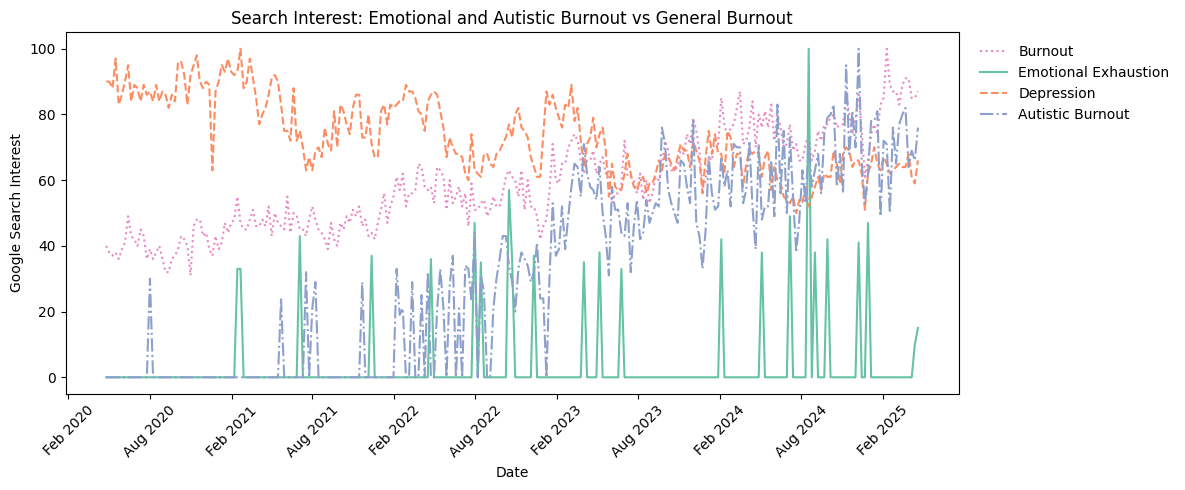

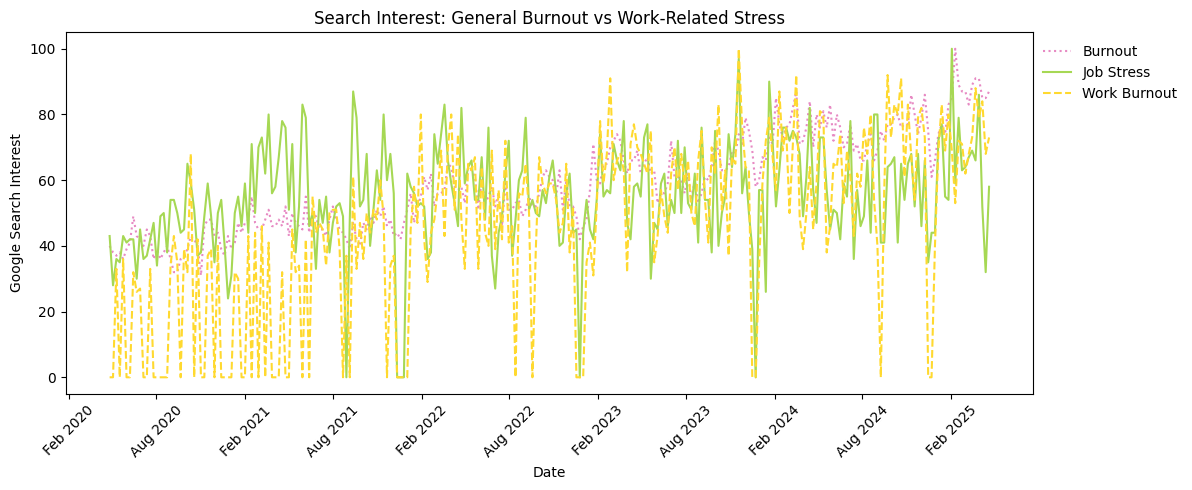

In [6]:
distinct_colors = sb.color_palette("Set2")

# Assign colors to each variable
colors = {
    "emotional exhaustion": distinct_colors[0],
    "depression": distinct_colors[1],
    "autistic burnout": distinct_colors[2],
    "burnout": distinct_colors[3],
    "job stress": distinct_colors[4],
    "work burnout": distinct_colors[5],
}

# Assign line styles
linestyles = {
    "emotional exhaustion": "-",
    "depression": "--",
    "autistic burnout": "-.",
    "burnout": ":",
    "job stress": "-",
    "work burnout": "--",
}

# Plot 1 (Time Series for Burnout and Mental Health Terms)
plt.figure(figsize=(12, 5))

sb.lineplot(x="Date", y="burnout", data=data, label="Burnout",
            color=colors["burnout"], linestyle=linestyles["burnout"])
sb.lineplot(x="Date", y="emotional exhaustion", data=data, label="Emotional Exhaustion",
            color=colors["emotional exhaustion"], linestyle=linestyles["emotional exhaustion"])
sb.lineplot(x="Date", y="depression", data=data, label="Depression",
            color=colors["depression"], linestyle=linestyles["depression"])
sb.lineplot(x="Date", y="autistic burnout", data=data, label="Autistic Burnout",
            color=colors["autistic burnout"], linestyle=linestyles["autistic burnout"])


plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.ylabel("Google Search Interest")
plt.title("Search Interest: Emotional and Autistic Burnout vs General Burnout")
plt.legend(loc='upper center', bbox_to_anchor=(1.13, 1), frameon=False)
plt.tight_layout()
plt.show()

# Plot 2 (Time Series for Burnout and Occupational Terms)
plt.figure(figsize=(12, 5))

sb.lineplot(x="Date", y="burnout", data=data, label="Burnout",
            color=colors["burnout"], linestyle=linestyles["burnout"])
sb.lineplot(x="Date", y="job stress", data=data, label="Job Stress",
            color=colors["job stress"], linestyle=linestyles["job stress"])
sb.lineplot(x="Date", y="work burnout", data=data, label="Work Burnout",
            color=colors["work burnout"], linestyle=linestyles["work burnout"])

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.ylabel("Google Search Interest")
plt.title("Search Interest: General Burnout vs Work-Related Stress")
plt.legend(loc='upper center', bbox_to_anchor=(1.08,1), frameon=False)
plt.tight_layout()
plt.show()

Summary Statistics and EDA

                      Date     burnout  job stress  emotional exhaustion  \
count                  261  261.000000  261.000000            261.000000   
mean   2022-10-23 00:00:00   58.881226   54.842912              3.532567   
min    2020-04-26 00:00:00   31.000000    0.000000              0.000000   
25%    2021-07-25 00:00:00   47.000000   45.000000              0.000000   
50%    2022-10-23 00:00:00   57.000000   54.000000              0.000000   
75%    2024-01-21 00:00:00   71.000000   66.000000              0.000000   
max    2025-04-20 00:00:00  100.000000  100.000000            100.000000   
std                    NaN   14.555903   16.198357             12.337088   

       depression  autistic burnout  work burnout  
count  261.000000        261.000000    261.000000  
mean    73.413793         31.781609     45.697318  
min     50.000000          0.000000      0.000000  
25%     64.000000          0.000000     33.000000  
50%     71.000000         33.000000     50.000000  
75%

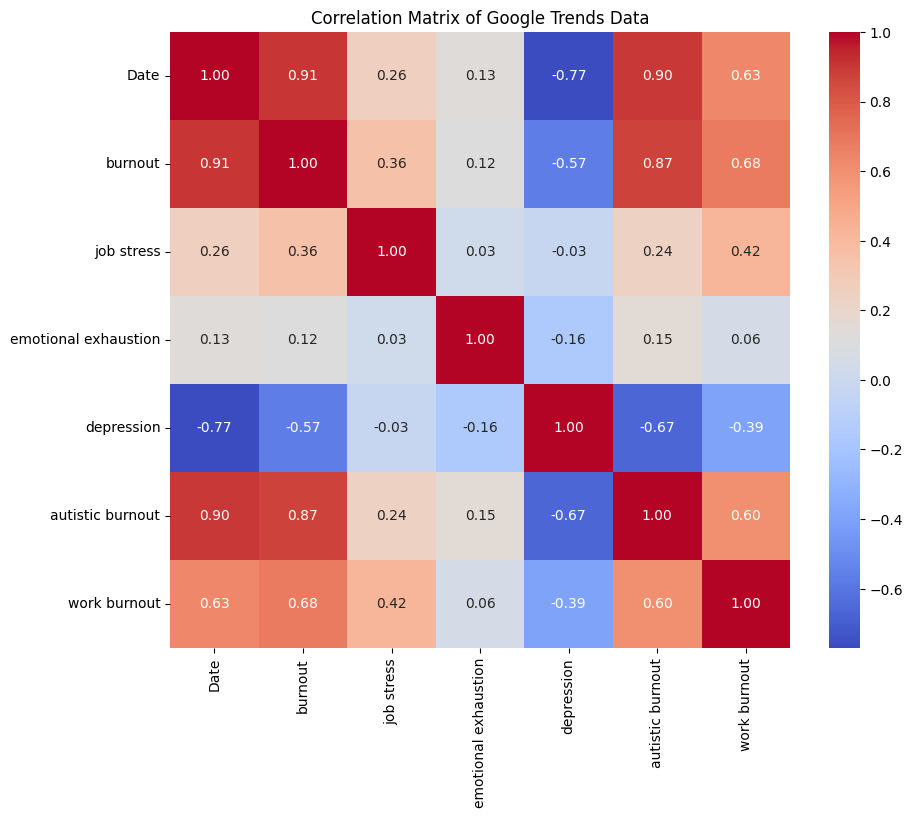

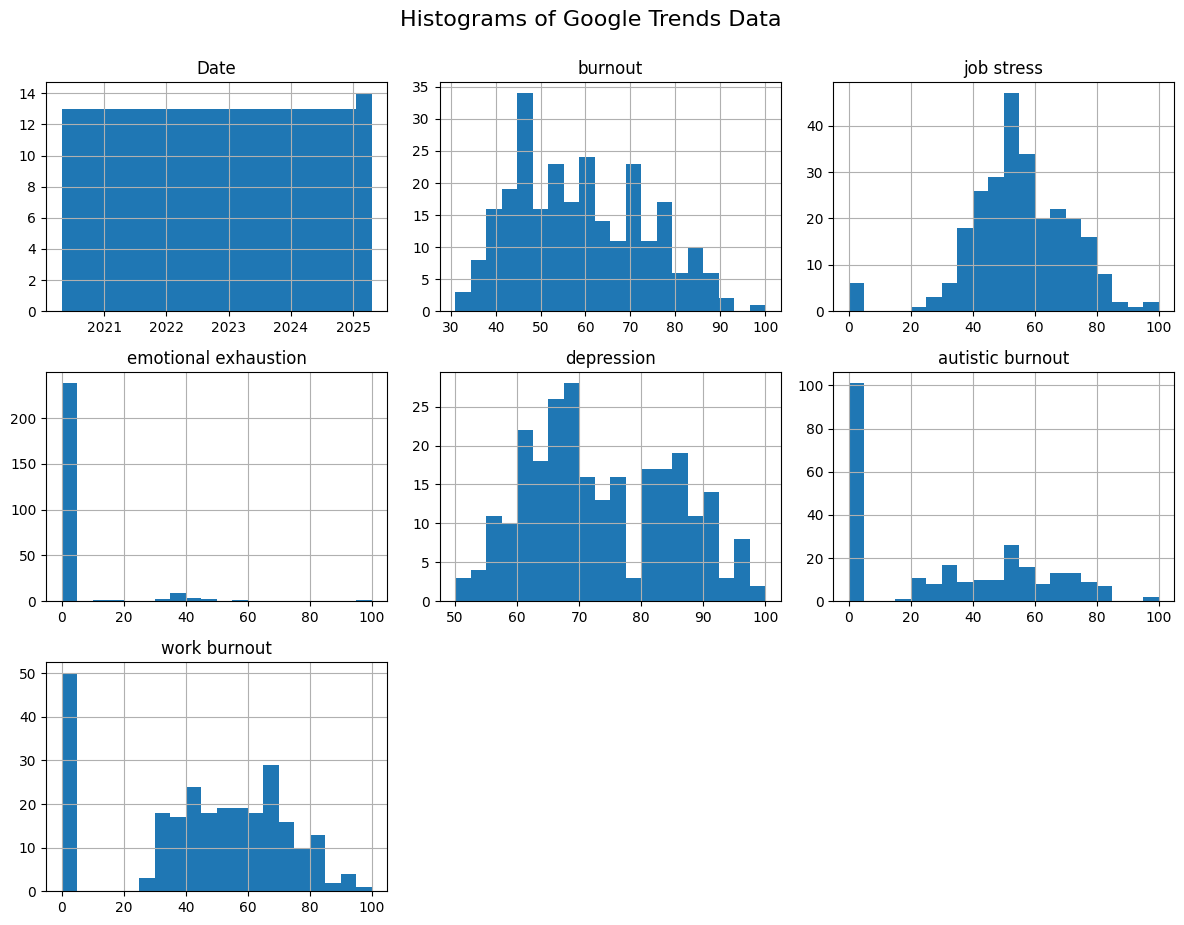

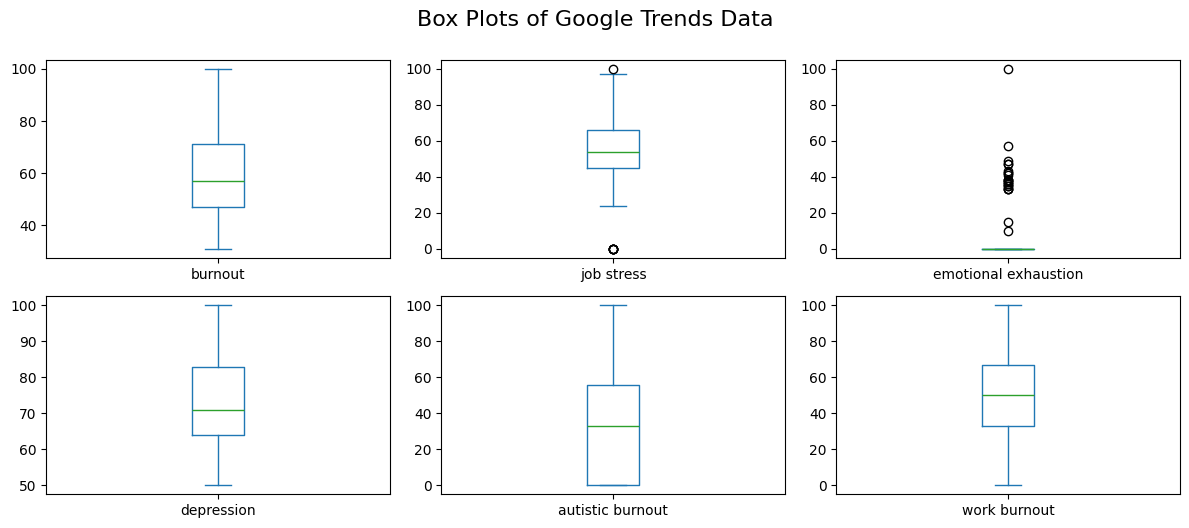

Skewness of burnout: 0.33187751799997417
Kurtosis of burnout: -0.7603692470173926
Skewness of job stress: -0.5254021414146458
Kurtosis of job stress: 1.6479478320330925
Skewness of emotional exhaustion: 3.967692984233465
Kurtosis of emotional exhaustion: 18.367722516104035
Skewness of depression: 0.24326601736323072
Kurtosis of depression: -0.9622439713177435
Skewness of autistic burnout: 0.1821398543174791
Kurtosis of autistic burnout: -1.3767075237630395
Skewness of work burnout: -0.5193794356319414
Kurtosis of work burnout: -0.7056409151046164


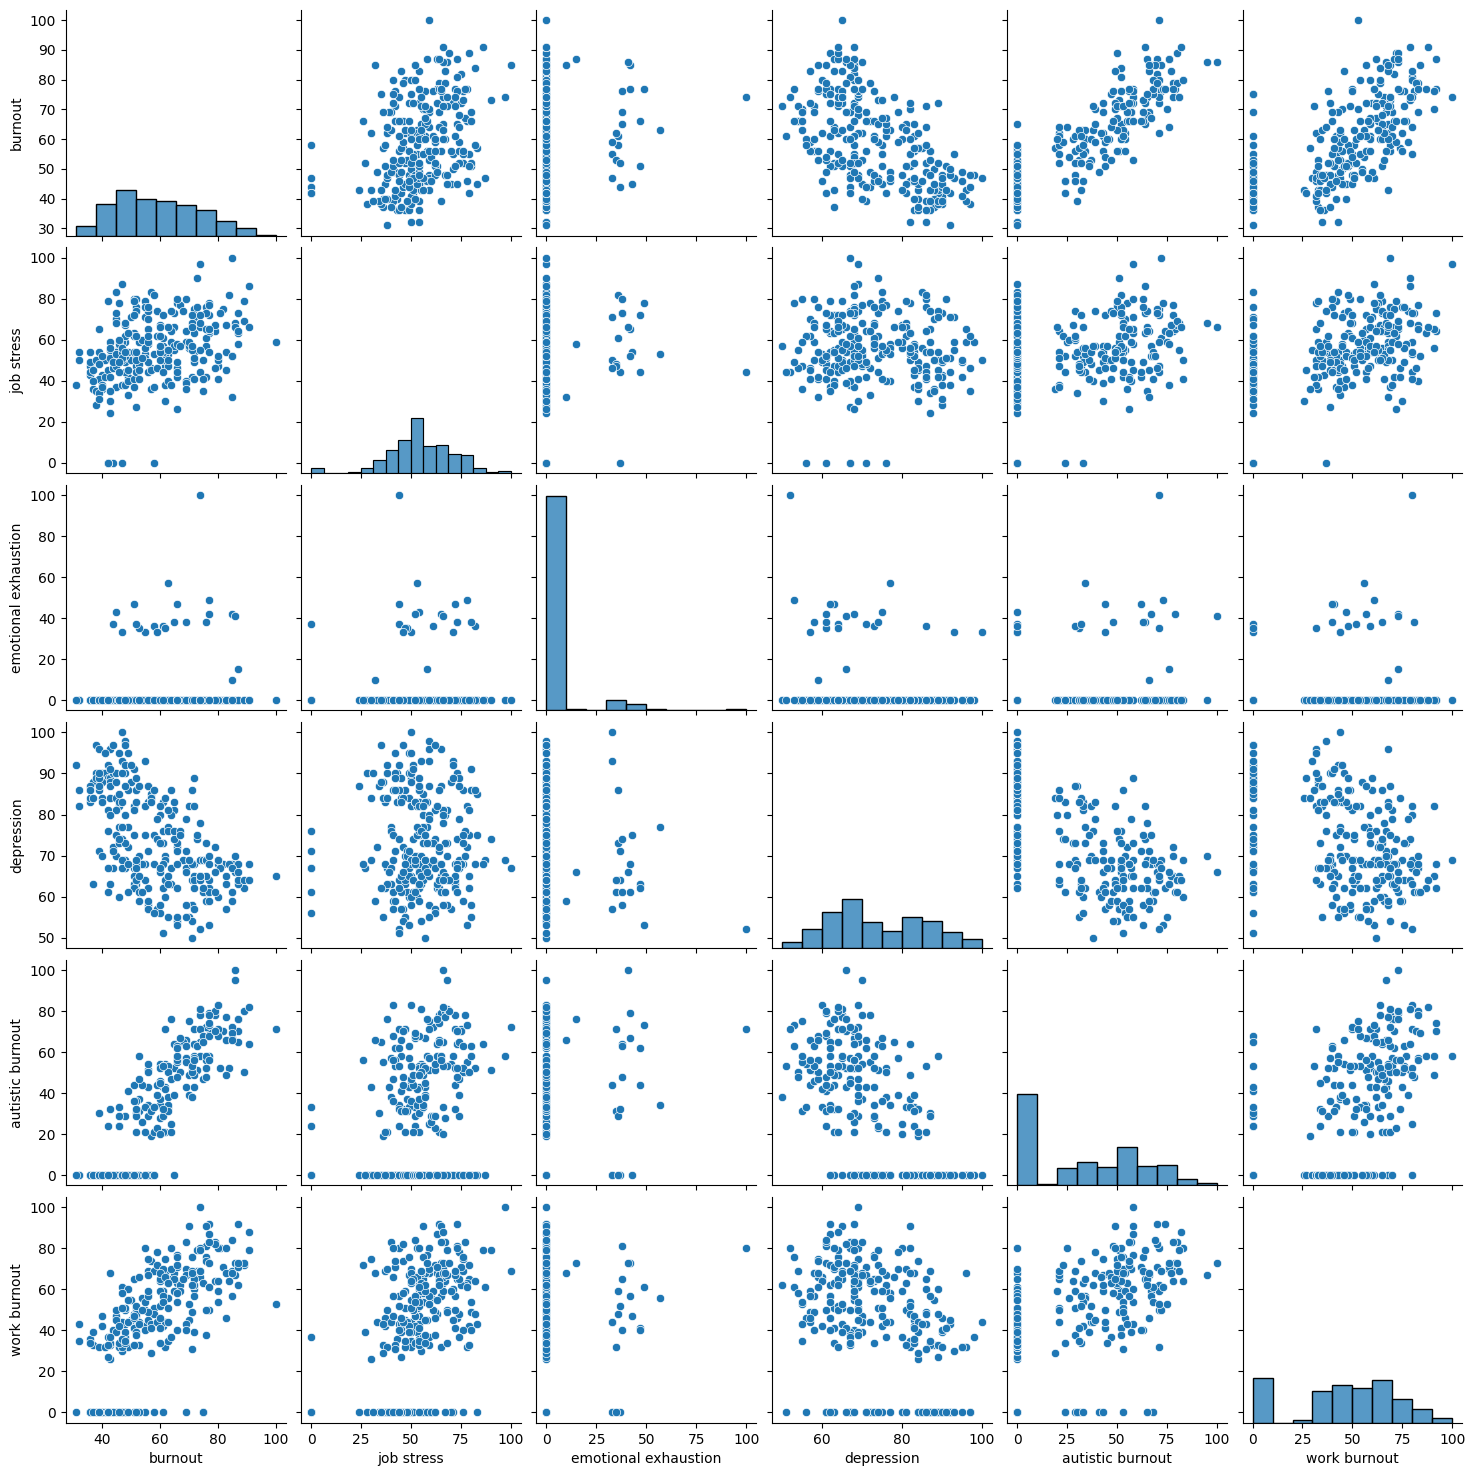

In [ ]:
# Summary Statistics
print(data.describe())

# Data Types
print(data.dtypes)

# Missing Values
print(data.isnull().sum())

# Correlation Matrix
correlation_matrix = data.corr()
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Google Trends Data')
plt.show()

# Histogram
data.hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms of Google Trends Data", y=0.95, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Box plot
data.plot(kind='box', subplots=True, layout=(3, 3), sharex=False, sharey=False, figsize=(12, 8))
plt.suptitle('Box Plots of Google Trends Data', y=0.95, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Skewness and Kurtosis
for col in data.columns[1:]:  # Exclude the 'Date' column
    print(f"Skewness of {col}: {skew(data[col])}")
    print(f"Kurtosis of {col}: {kurtosis(data[col])}")

# Pairplot
sb.pairplot(data)
plt.show()


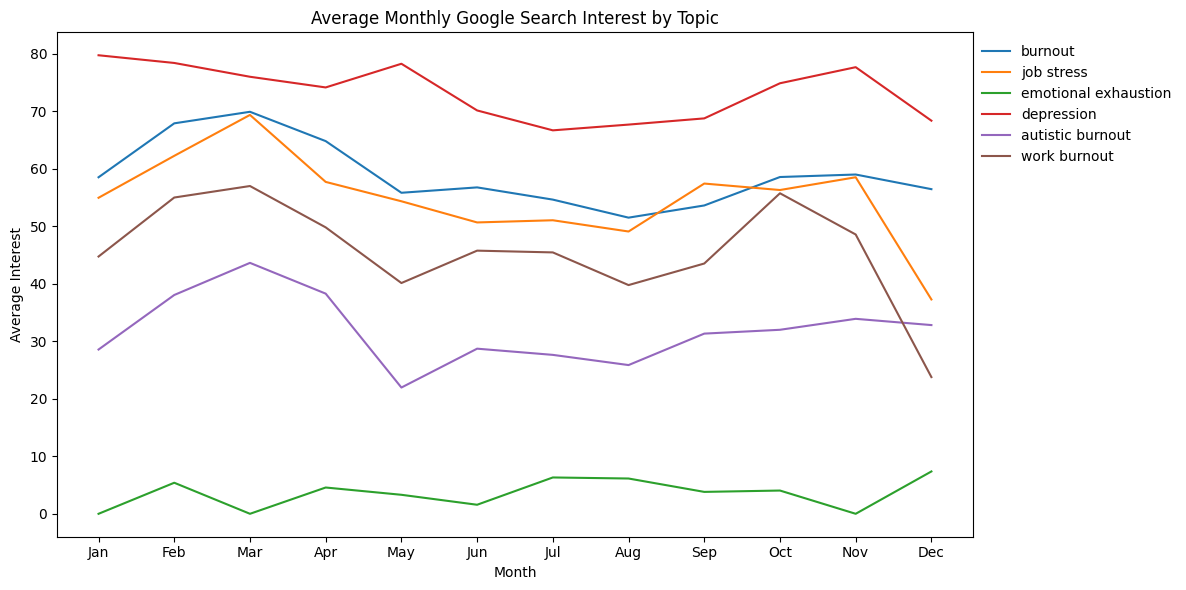

In [ ]:
# Ensure 'Date' is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the month as a number (1=Jan, 12=Dec)
data['Month'] = data['Date'].dt.month

# Group by month and calculate mean search interest for each variable (excluding Date)
monthly_avg = data.drop(columns='Date').groupby('Month').mean()

# Plot
plt.figure(figsize=(12, 6))
for column in monthly_avg.columns:
    plt.plot(monthly_avg.index, monthly_avg[column], label=column)

plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Average Monthly Google Search Interest by Topic")
plt.xlabel("Month")
plt.ylabel("Average Interest")
plt.legend(loc='upper right', bbox_to_anchor=(1.23, 1), frameon=False)
plt.tight_layout()
plt.show()


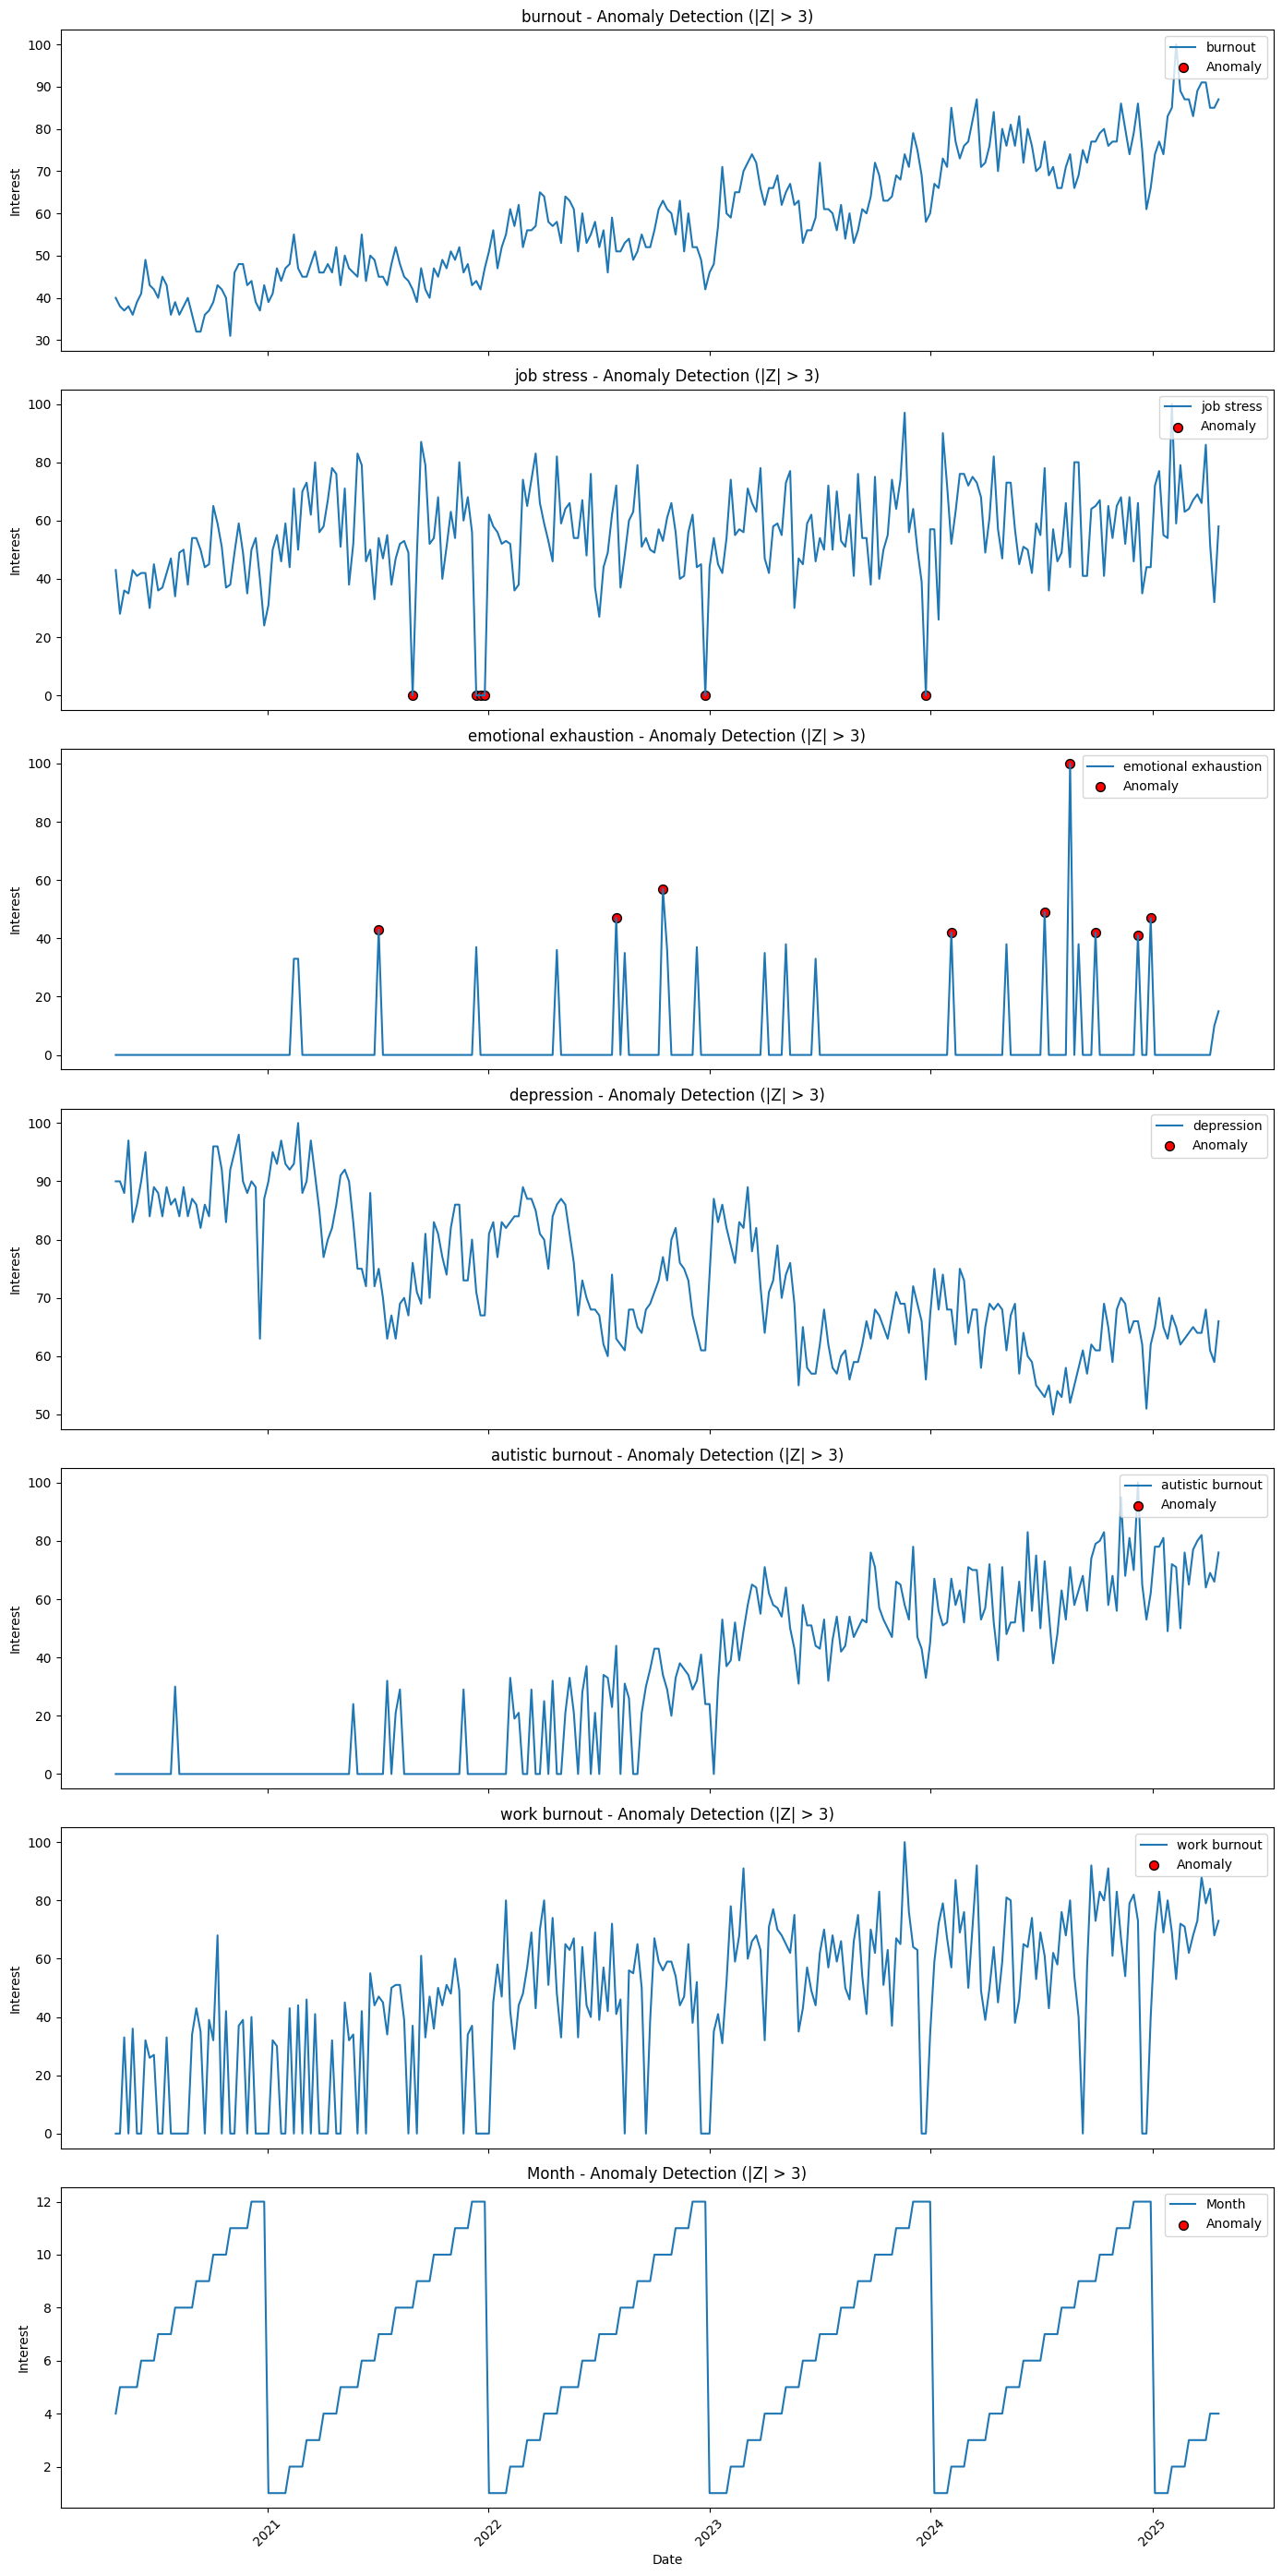

In [ ]:
# Drop Date column and compute Z-scores
search_data = data.drop(columns='Date')
z_scores = (search_data - search_data.mean()) / search_data.std()
threshold = 3
anomalies = z_scores.abs() > threshold

# Set up subplots
num_vars = len(search_data.columns)
fig, axes = plt.subplots(num_vars, 1, figsize=(14, 4 * num_vars), sharex=True)

# Loop through each variable
for i, col in enumerate(search_data.columns):
    ax = axes[i]

    # Plot the time series
    ax.plot(data['Date'], data[col], label=col, color='tab:blue')

    # Plot anomalies
    ax.scatter(
        data['Date'][anomalies[col]],
        data[col][anomalies[col]],
        color='red', s=50, label='Anomaly', marker='o', edgecolors='black'
    )

    ax.set_title(f"{col} - Anomaly Detection (|Z| > {threshold})")
    ax.set_ylabel("Interest")
    ax.legend(loc='upper right')

# Set common x-label
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


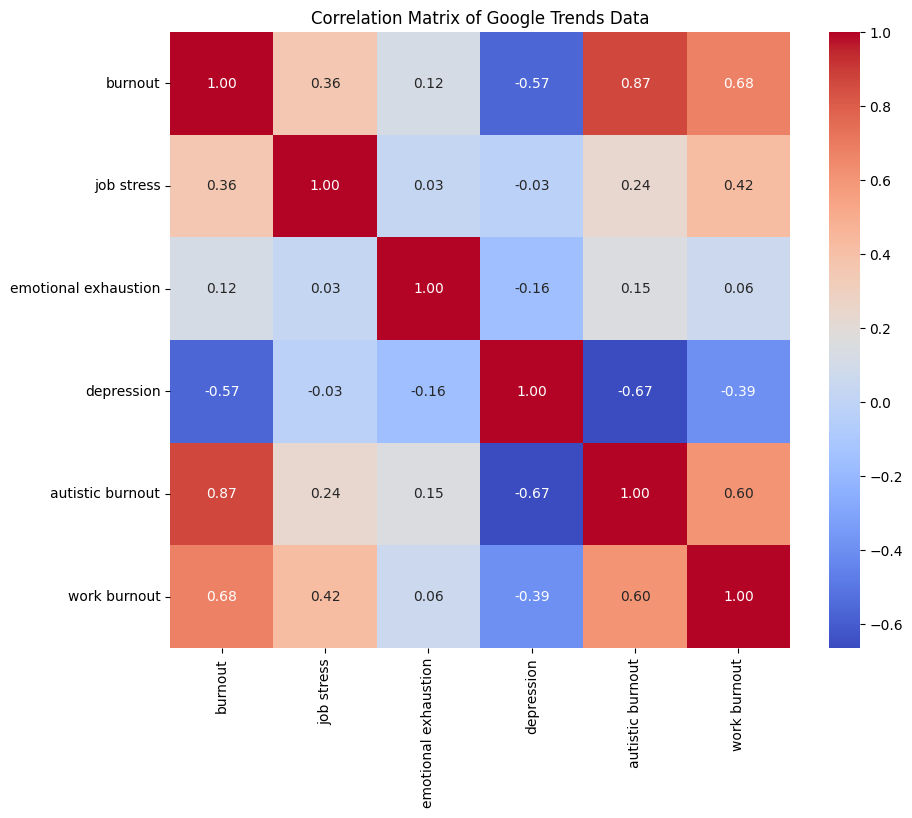

In [16]:
# Create a new DataFrame without the 'Date' column
data_no_date = data.drop(columns=['Date'])

# Calculate the correlation matrix
correlation_matrix_no_date = data_no_date.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sb.heatmap(correlation_matrix_no_date, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Google Trends Data')
plt.show()


Point Cloud A

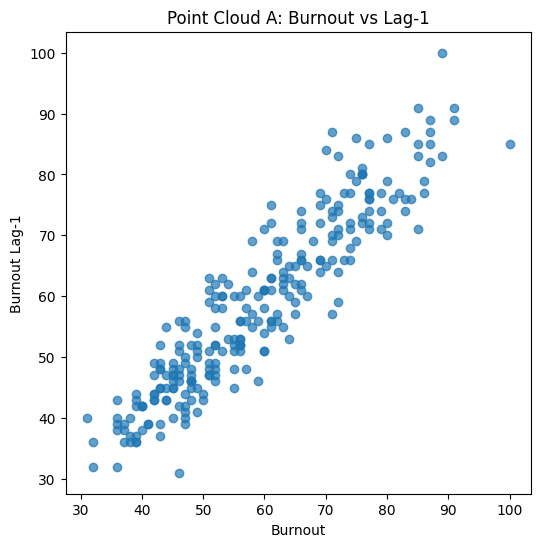

In [18]:
# Create lagged series (Lag-1)
data['burnout_lag1'] = data['burnout'].shift(1)

# Drop any rows with NaN caused by shifting
point_cloud = data.dropna(subset=['burnout', 'burnout_lag1'])

# Convert to NumPy array for TDA tools like Gudhi
cloud_A = point_cloud[['burnout', 'burnout_lag1']].to_numpy()

# Visualize the point cloud
plt.figure(figsize=(6, 6))
plt.scatter(cloud_A[:, 0], cloud_A[:, 1], alpha=0.7)
plt.title('Point Cloud A: Burnout vs Lag-1')
plt.xlabel('Burnout')
plt.ylabel('Burnout Lag-1')
plt.show()


Persistence Diagram for Cloud A

/usr/local/lib/python3.11/dist-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

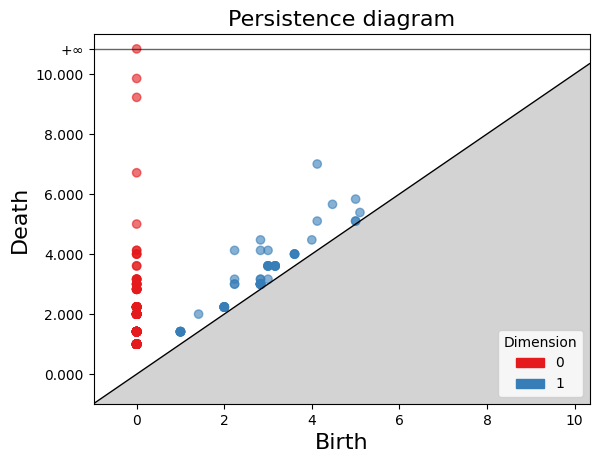

In [19]:
import gudhi.representations

# Build the Rips complex
rips_complex = gd.RipsComplex(points=cloud_A, max_edge_length=20.0)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

# Compute persistence diagram
diag = simplex_tree.persistence()

# Filter out dimension 0 or 1 features
persistence_pairs = simplex_tree.persistence_intervals_in_dimension(1)

# Plot the persistence diagram
gd.plot_persistence_diagram(diag)


Point Cloud B

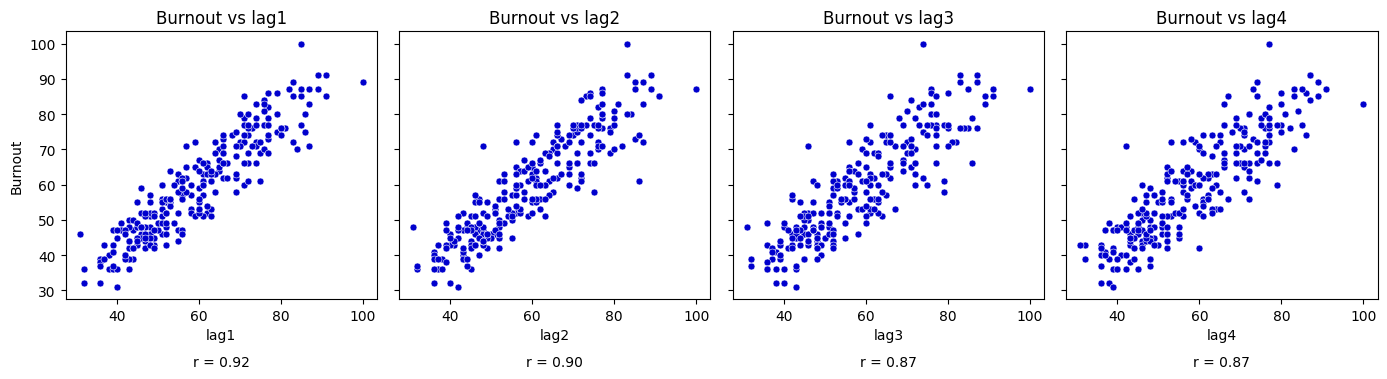

In [ ]:
# Extract and prepare burnout series
burnout_series = data[['Date', 'burnout']].copy().dropna().reset_index(drop=True)

# Create lagged features (lags 1 to 4)
for lag in range(1, 5):
    burnout_series[f'lag{lag}'] = burnout_series['burnout'].shift(lag)

# Drop rows with NaNs introduced by lagging
burnout_lags = burnout_series.dropna().reset_index(drop=True)

# Define lag column names
lags = [f"lag{l}" for l in range(1, 5)]

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

# Plot each lag vs current burnout search interest
for i, lag in enumerate(lags):
    ax = axes[i]
    sb.scatterplot(
        data=burnout_lags,
        x=lag,
        y="burnout",
        s=25,
        color="mediumblue",
        ax=ax
    )

    # Axis labels
    ax.set_xlabel(f"{lag}")
    if i == 0:
        ax.set_ylabel("Burnout")
    else:
        ax.set_ylabel("")

    # Correlation annotation
    r = burnout_lags[lag].corr(burnout_lags["burnout"])
    ax.annotate(f"r = {r:.2f}", xy=(0.5, -0.25), xycoords="axes fraction",
                ha='center', fontsize=10)

    ax.set_title(f"Burnout vs {lag}")

# Layout & save
plt.tight_layout()
plt.savefig("burnout_lags_plot.png", dpi=300)
plt.show()


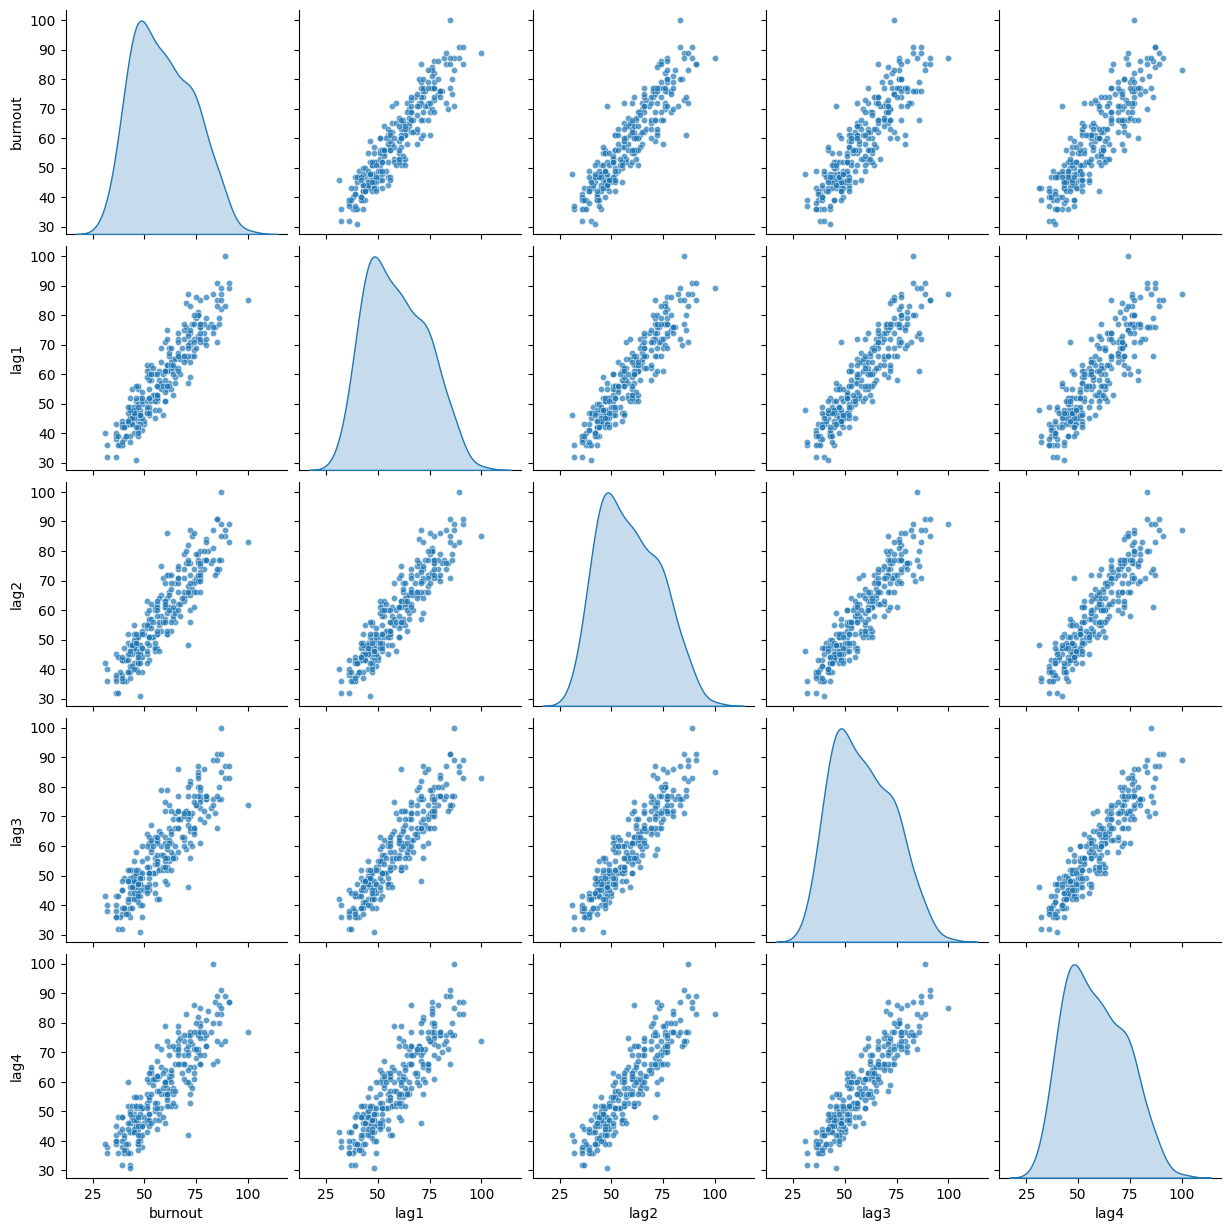

In [ ]:
# Select only relevant columns: burnout and its lags
pairplot_data = burnout_lags[['burnout', 'lag1', 'lag2', 'lag3', 'lag4']]

# Create the pairplot
sns.pairplot(pairplot_data, diag_kind='kde', plot_kws={'s': 20, 'alpha': 0.7})

# Save and show
plt.savefig("burnout_lags_pairplot.png", dpi=300)
plt.show()


Point Cloud C

Shape of Cloud C: (261, 2)


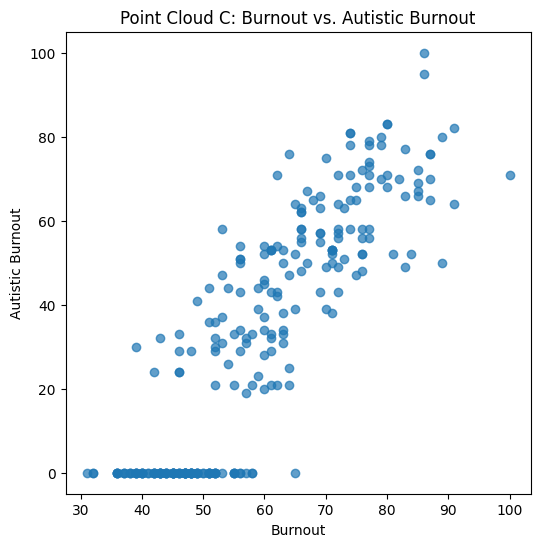

In [ ]:
# Drop missing values
point_cloud_C = data.dropna(subset=['burnout', 'autistic burnout'])

# Convert to numpy array
cloud_C = point_cloud_C[['burnout', 'autistic burnout']].to_numpy()

print("Shape of Cloud C:", cloud_C.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(cloud_C[:, 0], cloud_C[:, 1], alpha=0.7)
plt.xlabel('Burnout')
plt.ylabel('Autistic Burnout')
plt.title('Point Cloud C: Burnout vs. Autistic Burnout')
plt.show()

Persistence Diagram for Point Cloud C

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

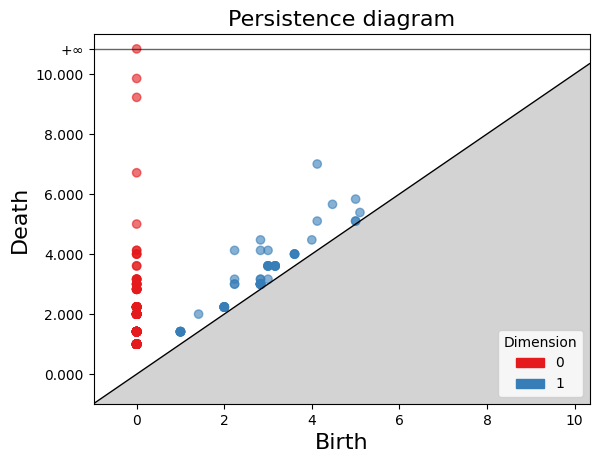

In [20]:
cloud_C = point_cloud[['burnout', 'burnout_lag1']].to_numpy()

# Step 1: Build the Rips complex
rips_complex = gd.RipsComplex(points=cloud_C, max_edge_length=20.0)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

# Step 2: Compute persistence diagram
diag = simplex_tree.persistence()

# Optional: Filter out dimension 0 or 1 features
persistence_pairs = simplex_tree.persistence_intervals_in_dimension(1)

# Step 3: Plot the persistence diagram
gd.plot_persistence_diagram(diag)

In [ ]:
data.head()


,Date,burnout,job stress,emotional exhaustion,depression,autistic burnout,work burnout,Month,burnout_lag1
0,2020-04-26,40,43,0,90,0,0,4,NaN
1,2020-05-03,38,28,0,90,0,0,5,40.0
2,2020-05-10,37,36,0,88,0,33,5,38.0
3,2020-05-17,38,35,0,97,0,0,5,37.0
4,2020-05-24,36,43,0,83,0,36,5,38.0


Time Series of Persistence Norms

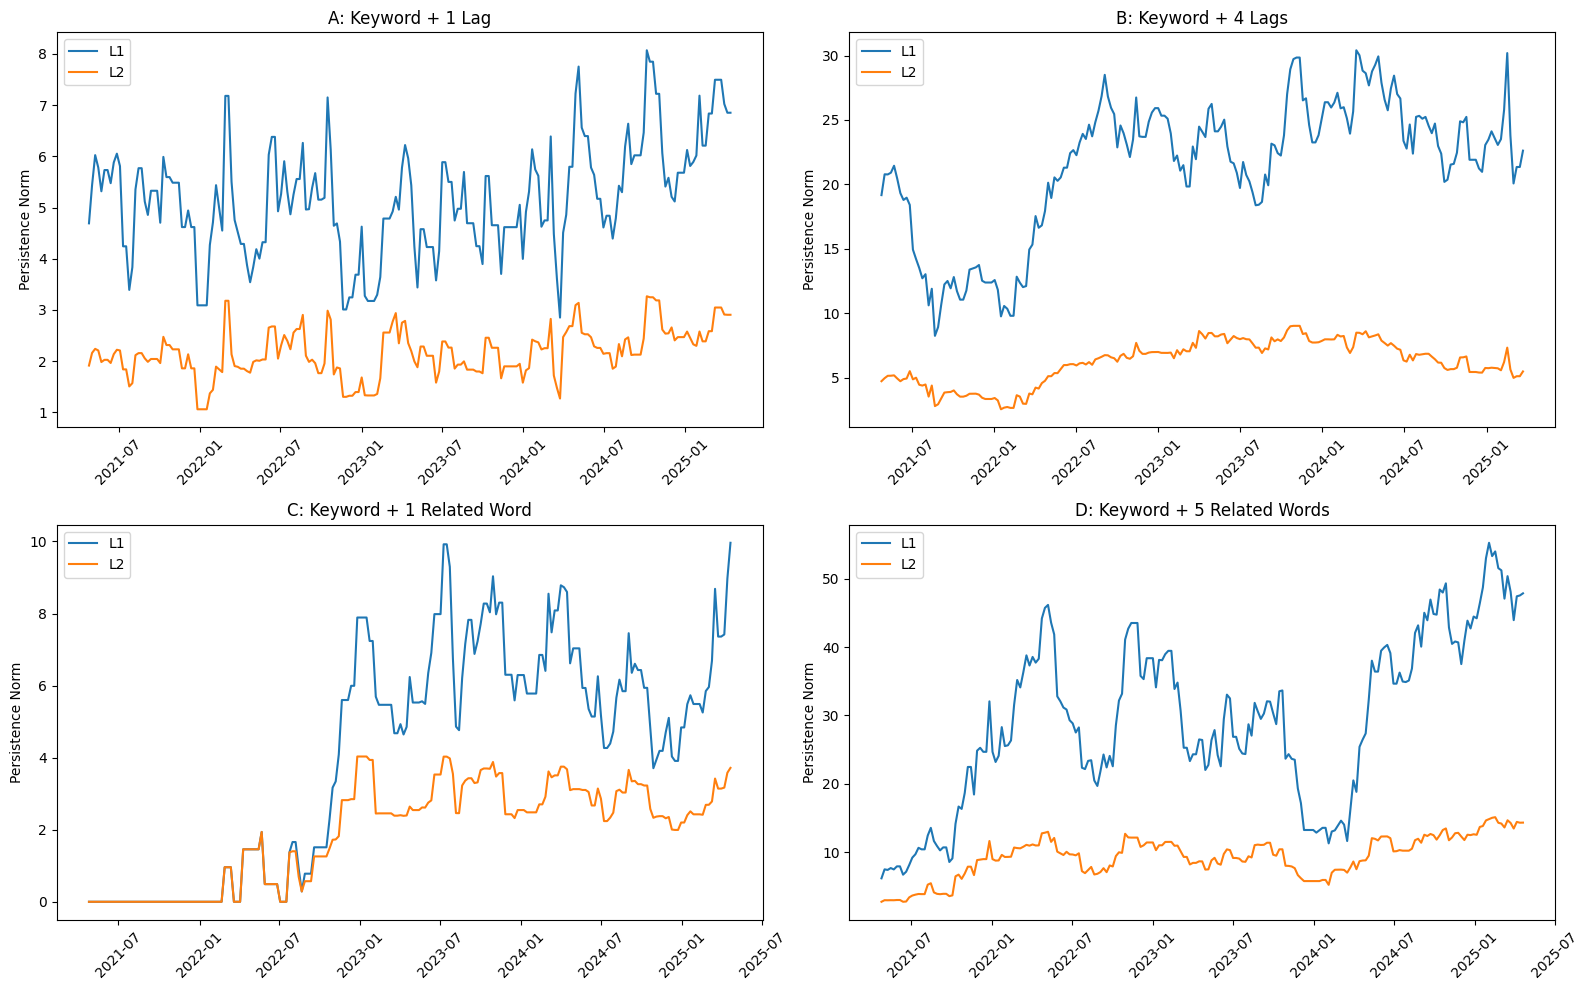

In [8]:
def compute_persistence_norms_and_diagrams(embed2, window_length=52, max_dim=2, radius=50):
    r, c = embed2.shape
    r2 = r - window_length
    norms = []
    diagrams_dim_1 = []

    for i in range(r2):
        window = embed2.iloc[i:i + window_length, :].to_numpy()
        rips = gd.RipsComplex(points=window, max_edge_length=radius)
        simplex_tree = rips.create_simplex_tree(max_dimension=max_dim)
        pers = simplex_tree.persistence()
        pers = [p for p in pers if np.isfinite(p[1][0]) and np.isfinite(p[1][1])]

        # Save dimension 1 diagram
        diag_dim_1 = [p[1] for p in pers if p[0] == 1]
        diagrams_dim_1.append(diag_dim_1)

        # Compute persistence norms
        L10 = sum(p[1][1] - p[1][0] for p in pers if p[0] == 0)
        L20 = math.sqrt(sum((p[1][1] - p[1][0]) ** 2 for p in pers if p[0] == 0))
        L11 = sum(p[1][1] - p[1][0] for p in pers if p[0] == 1)
        L21 = math.sqrt(sum((p[1][1] - p[1][0]) ** 2 for p in pers if p[0] == 1))

        norms.append([i + window_length, L10, L11, L20, L21])

    df = pd.DataFrame(norms, columns=['Obs', 'L10', 'L11', 'L20', 'L21'])
    return df, diagrams_dim_1

def plot_norms_subplot(norms_df, merged_df, ax, title):
    dff = merged_df[['Date']].copy()
    dff['Obs'] = dff.index
    merged = dff.merge(norms_df, on='Obs')

    df_long = merged.melt(id_vars=['Date'], value_vars=['L11', 'L21'],
                          var_name='Type', value_name='Persistence Norm')
    df_long['Type'] = df_long['Type'].replace({'L11': 'L1', 'L21': 'L2'})

    sb.lineplot(x='Date', y='Persistence Norm', hue='Type', data=df_long, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Persistence Norm')
    ax.tick_params(axis='x', rotation=45)
    ax.legend().set_title('')

# Create embeddings
embed_A = pd.concat([data['burnout'], data['burnout'].shift(1)], axis=1).dropna()
embed_B = pd.concat([data['burnout']] + [data['burnout'].shift(i) for i in range(1, 5)], axis=1).dropna()
embed_C = pd.concat([data['burnout'], data['autistic burnout']], axis=1).dropna()
related_cols = ['burnout', 'job stress', 'emotional exhaustion', 'depression', 'autistic burnout', 'work burnout']
embed_D = data[related_cols].dropna()

# Compute norms and save diagrams
norms_A, diagrams_A = compute_persistence_norms_and_diagrams(embed_A)
norms_B, diagrams_B = compute_persistence_norms_and_diagrams(embed_B)
norms_C, diagrams_C = compute_persistence_norms_and_diagrams(embed_C)
norms_D, diagrams_D = compute_persistence_norms_and_diagrams(embed_D)

# Plot
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

plot_norms_subplot(norms_A, data.reset_index(drop=True), axs[0, 0], 'A: Keyword + 1 Lag')
plot_norms_subplot(norms_B, data.reset_index(drop=True), axs[0, 1], 'B: Keyword + 4 Lags')
plot_norms_subplot(norms_C, data.reset_index(drop=True), axs[1, 0], 'C: Keyword + 1 Related Word')
plot_norms_subplot(norms_D, data.reset_index(drop=True), axs[1, 1], 'D: Keyword + 5 Related Words')

plt.tight_layout()
plt.show()



Time Series of Wasserstein Distance

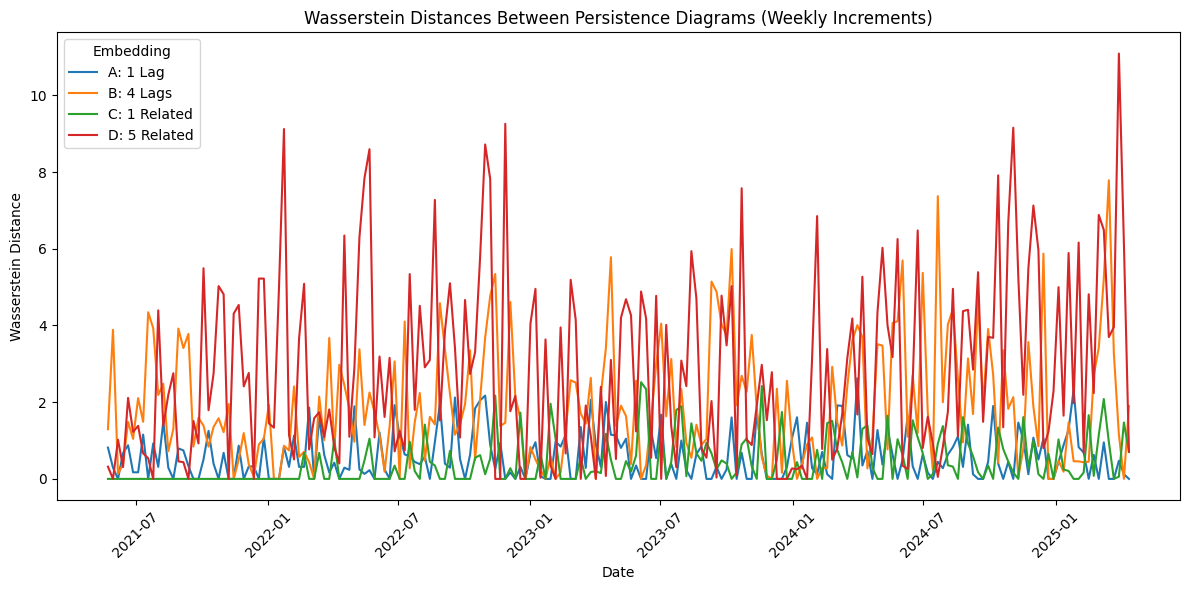

In [15]:
from gudhi.wasserstein import wasserstein_distance

# Compute persistence diagrams
def compute_persistence_diagrams(embed, window_length=52, max_dim=2, radius=50):
    diagrams = []
    for i in range(len(embed) - window_length):
        window = embed.iloc[i:i + window_length].to_numpy()
        rips = gd.RipsComplex(points=window, max_edge_length=radius)
        st = rips.create_simplex_tree(max_dimension=max_dim)
        pers = st.persistence()
        pers = [p for p in pers if np.isfinite(p[1][0]) and np.isfinite(p[1][1])]
        diag_1 = [p[1] for p in pers if p[0] == 1]
        if not diag_1:
            diagrams.append(np.empty((0, 2)))
        else:
            diagrams.append(np.array(diag_1))
    return diagrams

# Compute Wasserstein time series
def compute_wasserstein_series(diagrams):
    distances = []
    for i in range(len(diagrams) - 1):
        d1 = diagrams[i]
        d2 = diagrams[i + 1]
        dist = wasserstein_distance(d1, d2, order=1., internal_p=2.)
        distances.append(dist)
    return distances

# Embeddings for A, B, C, D
embed_A = pd.concat([data['burnout'], data['burnout'].shift(1)], axis=1).dropna()
embed_B = pd.concat([data['burnout']] + [data['burnout'].shift(i) for i in range(1, 5)], axis=1).dropna()
embed_C = pd.concat([data['burnout'], data['autistic burnout']], axis=1).dropna()
embed_D = data[['burnout', 'job stress', 'emotional exhaustion', 'depression', 'autistic burnout', 'work burnout']].dropna()

# Diagrams
diagrams_A = compute_persistence_diagrams(embed_A)
diagrams_B = compute_persistence_diagrams(embed_B)
diagrams_C = compute_persistence_diagrams(embed_C)
diagrams_D = compute_persistence_diagrams(embed_D)

# Wasserstein distances
wd_A = compute_wasserstein_series(diagrams_A)
wd_B = compute_wasserstein_series(diagrams_B)
wd_C = compute_wasserstein_series(diagrams_C)
wd_D = compute_wasserstein_series(diagrams_D)

# Calculate the minimum length of the Wasserstein distance series
min_len = min(len(wd_A), len(wd_B), len(wd_C), len(wd_D))

# Adjust the starting index to account for lag and windowing
start_index = 53 + (len(wd_A) - min_len)

# Slice the date index to the minimum length
base_date_index = data['Date'][start_index : start_index + min_len].reset_index(drop=True)

# Truncate Wasserstein distance series to the minimum lengths
wd_A = wd_A[-(min_len):]
wd_B = wd_B[-(min_len):]
wd_C = wd_C[-(min_len):]
wd_D = wd_D[-(min_len):]

# Create DataFrame for plotting
wasserstein_df = pd.DataFrame({
    'Date': base_date_index,
    'A: 1 Lag': wd_A,
    'B: 4 Lags': wd_B,
    'C: 1 Related': wd_C,
    'D: 5 Related': wd_D
})

# Melt and Plot
df_long = wasserstein_df.melt(id_vars='Date', var_name='Embedding', value_name='Wasserstein Distance')
plt.figure(figsize=(12, 6))
sb.lineplot(data=df_long, x='Date', y='Wasserstein Distance', hue='Embedding')
plt.xticks(rotation=45)
plt.title('Wasserstein Distances Between Persistence Diagrams (Weekly Increments)')
plt.tight_layout()
plt.show()